# Image Analysis

## YOLO

**YOLO (You Only Look Once)** is a *series of convolutional neural networks* for real-time object detection.
It started in 2015 (by Joseph Redmon) and evolved through versions:

| Generation    | Creator / Team                  | Framework           | Year      | Key Feature                                             |
| ------------- | ------------------------------- | ------------------- | --------- | ------------------------------------------------------- |
| **YOLOv1–v3** | Joseph Redmon (original author) | Darknet (C)         | 2015–2018 | Real-time, end-to-end detection                         |
| **YOLOv4**    | Alexey Bochkovskiy              | Darknet → PyTorch   | 2020      | Better training pipeline                                |
| **YOLOv5**    | *Ultralytics*                   | PyTorch             | 2020      | Easier to use, modern Python API                        |
| **YOLOv6–v7** | Meituan & WongKinYiu            | PyTorch             | 2022      | Speed/accuracy tweaks                                   |
| **YOLOv8**    | **Ultralytics**                 | PyTorch (rewritten) | 2023–2025 | Unified API for detection, segmentation, pose, tracking |

YOLOv8 is the latest generation maintained by Ultralytics, not just a fork — they own and evolve the modern PyTorch implementation.


## And who are *Ultralytics*?

[`ultralytics`](https://www.ultralytics.com/) is both:

* a company (they develop the YOLOv5/YOLOv8 series and Ultralytics Hub cloud service), and
* a Python package (`ultralytics`) that wraps the latest YOLO models in a clean API.

That’s why when you write:

```python
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
```

you’re:

* loading **a YOLOv8 model architecture**,
* through **Ultralytics’ framework**,
* implemented in **PyTorch**,
* optionally connected to their **Hub**.


“Ultralytics” *is* YOLOv8 — the official, maintained continuation of the YOLO series.

[`ultralytics`](https://www.ultralytics.com/) provides a **unified Python API** for several computer vision tasks using YOLOv8 models:

- **Detection** (bounding boxes)
- **Instance Segmentation** (per-object masks)
- **Image Classification** (labels)
- **Pose Estimation** (keypoints)
- **Multi-object Tracking** (video)
- **Oriented Bounding Boxes (OBB)** for rotated objects
- **Training** on custom data, **validation**, **export** (ONNX/TensorRT/CoreML/etc.)

## How to Run

YOLO is a library with several dependencies and supporting files, so installing it can take a bit of time and effort — like many other machine learning libraries. Since some tasks can also be quite computationally demanding, it’s a good idea to start in **Google Colab**. You can always install it locally later if you prefer.

## Example Files

Ultralytics provides a GitHub repository with several example files that you can open and experiment with directly in Colab. Here’s how to open one of them from Google Colab:

![open](Screenshot%202025-10-29%20221443.png)


### Installation in google colab

In [ ]:
!pip -q install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.1 MB/s eta 0:00:00


### Object Detection - Example Code

Detect objects with bounding boxes. Start with the **nano** checkpoint for speed: `yolov8n.pt`.


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 215.1ms
Speed: 5.0ms preprocess, 215.1ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 480)


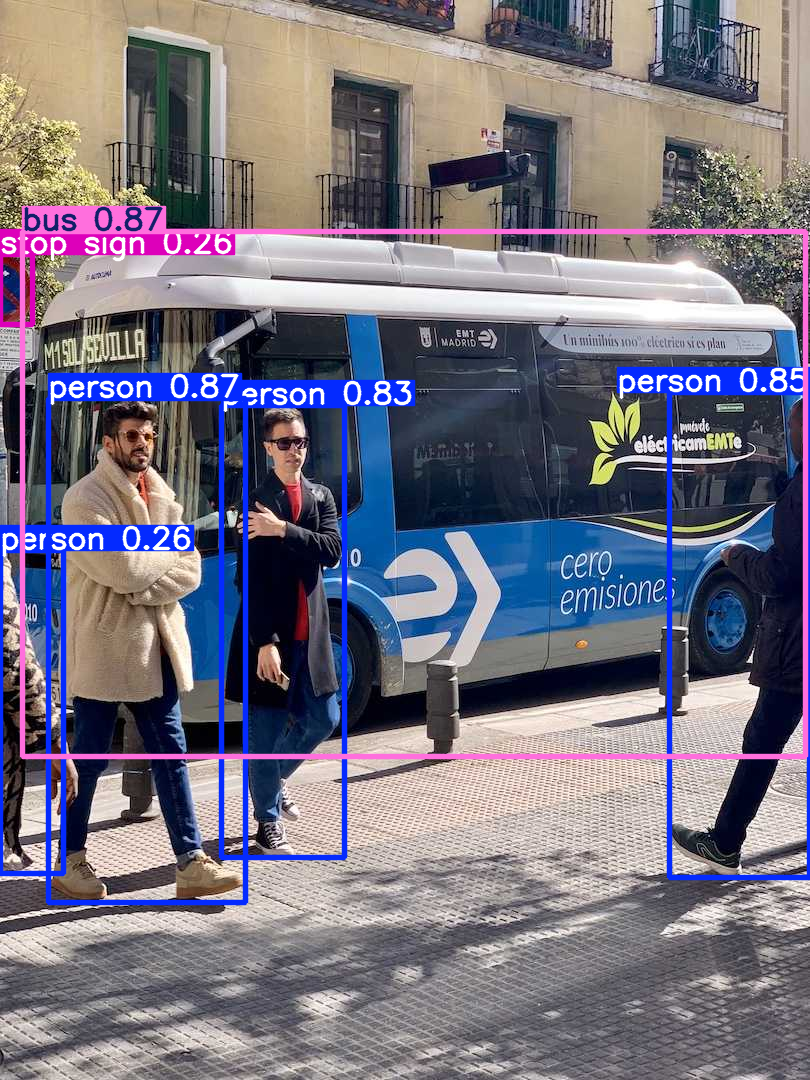

,0,1,2,3
0,22.871269,231.277313,805.002686,756.840332
1,48.550468,398.552216,245.345566,902.702698
2,669.472900,392.186127,809.720154,877.035461
3,221.517288,405.798645,344.970612,857.536621
4,0.000000,550.525024,63.006950,873.442932
5,0.058171,254.459396,32.557407,324.874146


In [ ]:
from ultralytics import YOLO
import pandas as pd
import os

detector = YOLO('yolov8n.pt')

img_path = "https://ultralytics.com/images/bus.jpg"

det_results = detector(img_path)
det_results[0].show()

# Convert results to pandas DataFrame
# Include bounding box coordinates (xyxy), confidence scores, class indices, and class names
results_df = pd.DataFrame(det_results[0].boxes.xyxy.cpu().numpy())
results_df.columns = ['x_min', 'y_min', 'x_max', 'y_max']

# Add confidence scores, class indices, and class names
results_df['confidence'] = det_results[0].boxes.conf.cpu().numpy()
results_df['class_id'] = det_results[0].boxes.cls.cpu().numpy().astype(int)
results_df['class_name'] = results_df['class_id'].apply(lambda x: det_results[0].names[x])

display(results_df)

# Save the DataFrame to a CSV file with the image name
img_filename = os.path.basename(img_path)
csv_filename = os.path.splitext(img_filename)[0] + '_detection_results.csv'
results_df.to_csv(csv_filename, index=False)
print(f"\nDetection results saved to '{csv_filename}'")

### Object Segmentation - Example Code


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 skateboard, 297.2ms
Speed: 5.7ms preprocess, 297.2ms inference, 20.1ms postprocess per image at shape (1, 3, 640, 480)


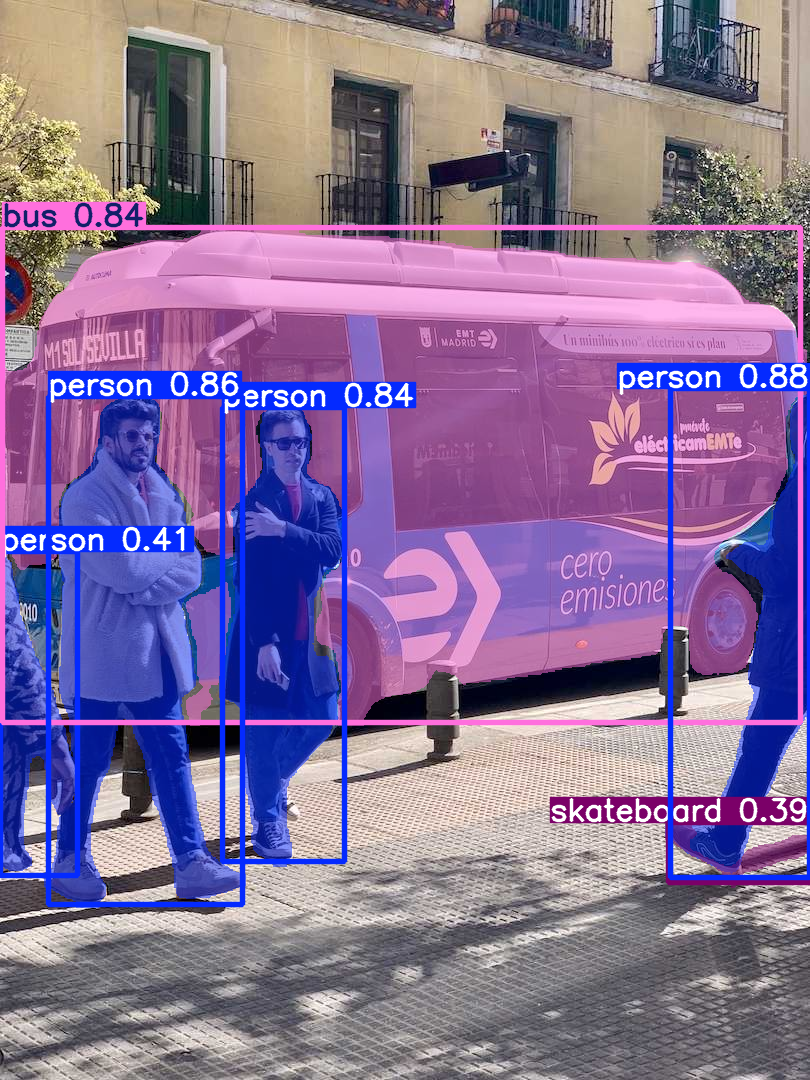


Segmentation performed and results displayed.


In [13]:
from ultralytics import YOLO
import pandas as pd
import os

# Load a segmentation model
segmentor = YOLO('yolov8n-seg.pt')

img_path = "https://ultralytics.com/images/bus.jpg"

# Perform segmentation
seg_results = segmentor(img_path)

# Show the results with segmentation masks
seg_results[0].show()


### Pose Estimation - Example Code


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 195.7ms
Speed: 3.7ms preprocess, 195.7ms inference, 5.7ms postprocess per image at shape (1, 3, 640, 480)


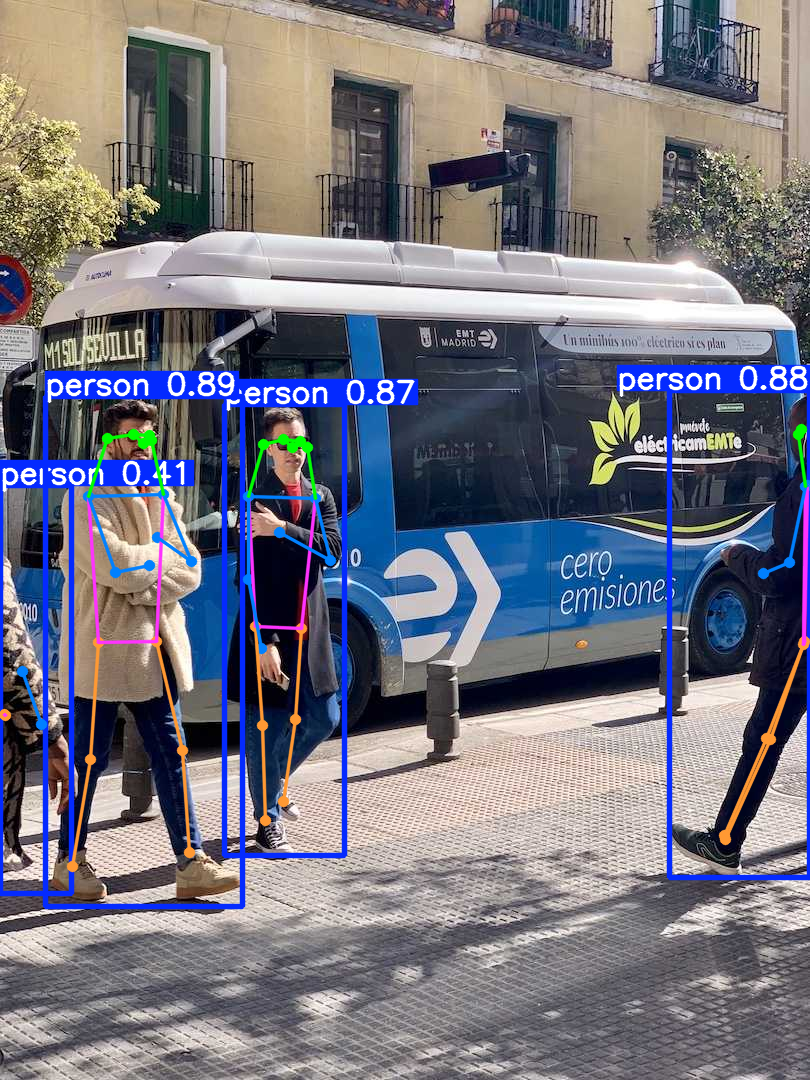


Keypoints data: ultralytics.engine.results.Keypoints object with attributes:

conf: tensor([[0.9834, 0.9026, 0.9725, 0.4235, 0.8832, 0.9880, 0.9944, 0.9423, 0.9838, 0.9081, 0.9681, 0.9963, 0.9976, 0.9922, 0.9955, 0.9649, 0.9755],
        [0.2480, 0.2881, 0.0780, 0.4205, 0.0768, 0.6773, 0.3295, 0.5977, 0.1352, 0.4842, 0.1554, 0.7036, 0.5158, 0.7901, 0.6256, 0.6794, 0.5560],
        [0.9790, 0.9192, 0.9572, 0.6509, 0.8552, 0.9927, 0.9960, 0.9578, 0.9788, 0.9308, 0.9568, 0.9974, 0.9979, 0.9942, 0.9957, 0.9758, 0.9802],
        [0.0150, 0.0116, 0.0076, 0.0448, 0.0246, 0.1564, 0.0814, 0.3230, 0.1354, 0.2901, 0.1455, 0.3322, 0.2588, 0.2427, 0.1918, 0.1332, 0.1128]])
data: tensor([[[1.4375e+02, 4.4351e+02, 9.8343e-01],
         [1.4906e+02, 4.3515e+02, 9.0262e-01],
         [1.3369e+02, 4.3469e+02, 9.7249e-01],
         [1.5199e+02, 4.4070e+02, 4.2355e-01],
         [1.0729e+02, 4.3899e+02, 8.8325e-01],
         [1.6319e+02, 4.9433e+02, 9.8804e-01],
         [8.8729e+01, 4.9641e+02, 9.9445e-

In [14]:
from ultralytics import YOLO
import pandas as pd
import os

# Load a pose estimation model
pose_estimator = YOLO('yolov8n-pose.pt') # Use a pose estimation model

img_path = "https://ultralytics.com/images/bus.jpg" # Or an image with people for pose estimation

# Perform pose estimation
pose_results = pose_estimator(img_path)

# Show the results with keypoints
pose_results[0].show()

# You can access keypoints data if needed
keypoints = pose_results[0].keypoints
print("\nKeypoints data:", keypoints)

print("\nPose estimation performed and results displayed.")

# Sentiment Alaysis

The code below gives a simple introduction to how images can be analysed in terms of their content and sentiment.
In this example, we’ll use a straightforward workflow that first converts an image into text (a caption), and then evaluates the sentiment of that text.

But first, we need to:

In [ ]:
!pip install transformers

## Image-to-text
### Step 1

```python
from transformers import pipeline
```

This imports the **`pipeline`** function from the  **Hugging Face Transformers** library.
`pipeline` is a high-level shortcut that lets you easily use pre-trained AI models (for text, images, audio, etc.) without dealing with the low-level details.



### Step 2

```python
url = "https://www.southlytchettmanor.co.uk/wp-content/uploads/2024/09/PRP-SLM-5486-2400x1600.jpg"
```

This line defines the **URL of an image** that the model will analyze.
In this case, it’s a link to a photo hosted on a website.



### Step 3

```python
captioner = pipeline("image-to-text", model="Salesforce/blip-image-captioning-base")
```

Here, you create a **pipeline** for the task `"image-to-text"`, also known as **image captioning**.
It uses the **Salesforce BLIP (Bootstrapped Language-Image Pretraining)** model — a neural network trained to describe images in natural language.
This means the model looks at an image and generates a short descriptive sentence about it.


### Step 4

```python
text = captioner(url)[0]['generated_text']
```

This line sends the image (via its URL) to the captioning model.

* `captioner(url)` runs the model on the image.
* It returns a list of results (each result is a dictionary).
* `[0]` takes the first result.
* `['generated_text']` extracts the actual caption (the text description).

So `text` now holds something like:

> `"A motorhome parked on a grassy campsite near trees."`



### Step 5

```python
print(text)
```

Finally, this prints the generated caption to the console.



### Summary

This short script:

1. Loads a pre-trained **image captioning** model.
2. Sends it an image from a URL.
3. Gets back a natural-language **description** of the image.
4. Prints that caption.

### Combined Code


In [ ]:

from transformers import pipeline
url ="https://www.southlytchettmanor.co.uk/wp-content/uploads/2024/09/PRP-SLM-5486-2400x1600.jpg"
captioner = pipeline("image-to-text", model="Salesforce/blip-image-captioning-base")
text = captioner(url)[0]['generated_text']
print(text)

## Text-to-sentiment

In [ ]:
from transformers import pipeline
sentiment = pipeline("sentiment-analysis")
print(sentiment(text))